In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
nav = pd.read_csv(r"D:\Projects\mutual_fund_analysis\data\raw\02_nav_history.csv")
txns = pd.read_csv(r"D:\Projects\mutual_fund_analysis\data\raw\08_investor_transactions.csv")
scheme_perf = pd.read_csv(r"D:\Projects\mutual_fund_analysis\data\raw\07_scheme_performance.csv")


In [11]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [12]:
print(nav.head(10))

   amfi_code        date      nav
0     119551  03-01-2022  54.3856
1     119551  04-01-2022  54.3474
2     119551  05-01-2022  54.6869
3     119551  06-01-2022  55.4550
4     119551  07-01-2022  55.3692
5     119551  10-01-2022  55.2835
6     119551  11-01-2022  56.0878
7     119551  12-01-2022  56.4978
8     119551  13-01-2022  56.2934
9     119551  14-01-2022  56.5926


In [13]:
print(nav['date'].sample(10))

9969     13-12-2024
28541    12-08-2025
19537    13-05-2026
15370    14-08-2023
31799    15-11-2024
22682    12-03-2025
9915     30-09-2024
10110    30-06-2025
6307     21-02-2024
33081    20-05-2025
Name: date, dtype: str


In [14]:
nav['date'] = pd.to_datetime(
    nav['date'],
    errors='coerce',
    dayfirst=True
)

In [15]:
print(nav['date'].isna().sum())

0


In [16]:
print(txns.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [17]:

nav['date'] = pd.to_datetime(
    nav['date'],
    dayfirst=True,
    errors='coerce'
)

txns['transaction_date'] = pd.to_datetime(
    txns['transaction_date'],
    errors='coerce'
)

print("NAV Shape:", nav.shape)
print("Transactions Shape:", txns.shape)
print("Scheme Performance Shape:", scheme_perf.shape)

NAV Shape: (46000, 3)
Transactions Shape: (32778, 13)
Scheme Performance Shape: (40, 19)


In [18]:
var_results = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == fund
    ].sort_values('date')

    returns = temp['nav'].pct_change().dropna()

    if len(returns) < 30:
        continue

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    var_results.append([
        fund,
        var95,
        cvar95
    ])

var_df = pd.DataFrame(
    var_results,
    columns=[
        'amfi_code',
        'VaR_95',
        'CVaR_95'
    ]
)

var_df.head()

,amfi_code,VaR_95,CVaR_95
0,119551,-0.012846,-0.016397
1,119552,-0.013501,-0.017336
2,119598,-0.024507,-0.030595
3,119599,-0.026859,-0.032384
4,119120,-0.003938,-0.005014


In [19]:
var_df.to_csv(
    "var_cvar_report.csv",
    index=False
)

print("CSV Exported")

CSV Exported


In [20]:
top5_funds = (
    nav['amfi_code']
    .value_counts()
    .head(5)
    .index
)

top5_funds

Index([119551, 119552, 119598, 119599, 119120], dtype='int64', name='amfi_code')

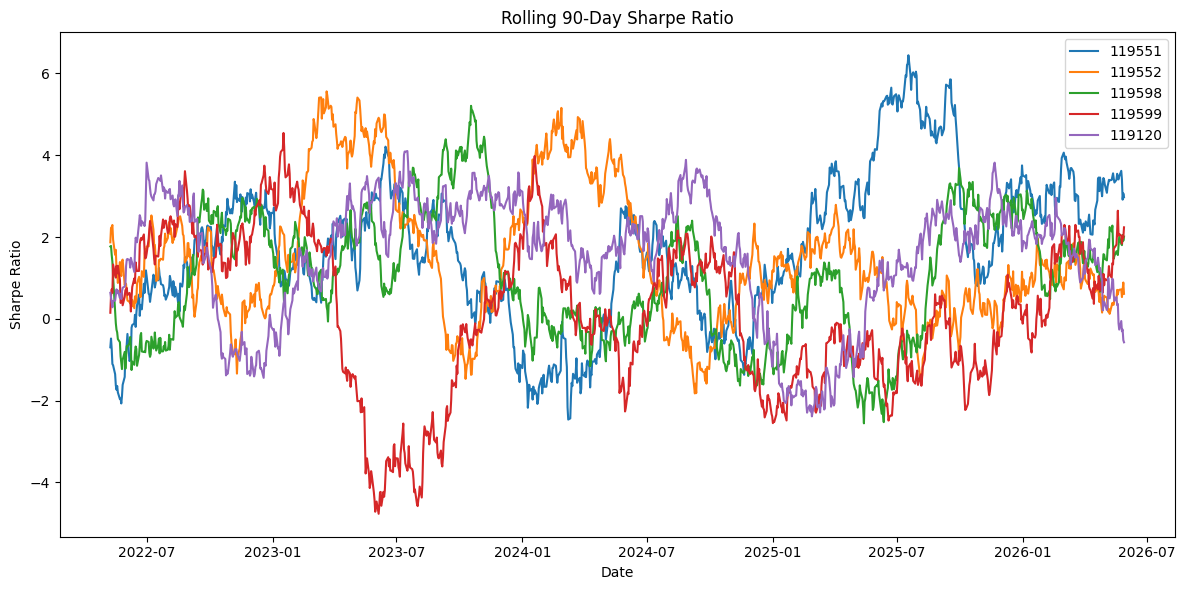

In [21]:
plt.figure(figsize=(12,6))

for fund in top5_funds:

    temp = nav[
        nav['amfi_code'] == fund
    ].sort_values('date')

    returns = temp['nav'].pct_change()

    rolling_sharpe = (
        returns.rolling(90).mean()
        /
        returns.rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        rolling_sharpe,
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.tight_layout()

plt.savefig(
    "rolling_sharpe_chart.png",
    dpi=300
)

plt.show()

In [22]:
first_txn = (
    txns.groupby('investor_id')
    ['transaction_date']
    .min()
    .reset_index()
)

first_txn['cohort_year'] = (
    first_txn['transaction_date']
    .dt.year
)

txns = txns.merge(
    first_txn[
        ['investor_id','cohort_year']
    ],
    on='investor_id'
)

txns.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [23]:
cohort_summary = (
    txns[
        txns['transaction_type']
        == 'SIP'
    ]
    .groupby('cohort_year')
    .agg(
        avg_sip_amount=(
            'amount_inr',
            'mean'
        ),
        total_invested=(
            'amount_inr',
            'sum'
        )
    )
)

cohort_summary

,avg_sip_amount,total_invested
cohort_year,,
2024,10996.885825,214978121
2025,13505.209581,2255370


In [24]:
top_funds = (
    txns.groupby(
        [
            'cohort_year',
            'amfi_code'
        ]
    )
    .size()
    .reset_index(
        name='count'
    )
)

top_funds = (
    top_funds
    .sort_values(
        'count',
        ascending=False
    )
    .groupby('cohort_year')
    .first()
)

top_funds

,amfi_code,count
cohort_year,,
2024,148568,874
2025,120507,12


In [25]:
sip_txns = txns[
    txns['transaction_type']
    == 'SIP'
].copy()

In [26]:
continuity_results = []

for inv in sip_txns[
    'investor_id'
].unique():

    temp = sip_txns[
        sip_txns['investor_id']
        == inv
    ].sort_values(
        'transaction_date'
    )

    if len(temp) < 6:
        continue

    avg_gap = (
        temp['transaction_date']
        .diff()
        .dt.days
        .mean()
    )

    status = (
        "At Risk"
        if avg_gap > 35
        else "Healthy"
    )

    continuity_results.append([
        inv,
        avg_gap,
        status
    ])

sip_continuity = pd.DataFrame(
    continuity_results,
    columns=[
        'investor_id',
        'avg_gap_days',
        'status'
    ]
)

sip_continuity.head()

,investor_id,avg_gap_days,status
0,INV003054,78.666667,At Risk
1,INV001497,63.000000,At Risk
2,INV000786,64.125000,At Risk
3,INV003670,70.857143,At Risk
4,INV001023,72.428571,At Risk


In [27]:
healthy = (
    sip_continuity['status']
    == 'Healthy'
).sum()

atrisk = (
    sip_continuity['status']
    == 'At Risk'
).sum()

total = len(sip_continuity)

continuity_rate = (
    healthy / total
) * 100

print(
    f"SIP Continuity Rate: {continuity_rate:.2f}%"
)

SIP Continuity Rate: 2.20%


In [28]:
risk_level = "High"

In [29]:
risk_level = "Low"
risk_level = "Moderate"
risk_level = "High"

In [30]:
recommend = (
    scheme_perf[
        scheme_perf['risk_grade']
        .str.lower()
        ==
        risk_level.lower()
    ]
    .sort_values(
        'sharpe_ratio',
        ascending=False
    )
    .head(3)
)

recommend[
    [
        'scheme_name',
        'risk_grade',
        'sharpe_ratio',
        'alpha',
        'return_3yr_pct'
    ]
]

,scheme_name,risk_grade,sharpe_ratio,alpha,return_3yr_pct
21,Kotak Emerging Equity Fund - Regular - Growth,High,0.96,1.91,18.23
12,ICICI Pru Midcap Fund - Regular - Growth,High,0.95,0.89,18.08
38,DSP Midcap Fund - Regular - Growth,High,0.90,1.02,17.16


# Advanced Insights

1. Funds with the lowest VaR and CVaR values exhibit the highest downside risk.

2. Rolling Sharpe analysis identifies funds with superior risk-adjusted returns.

3. Investor cohort analysis reveals which cohort contributes the highest investment volume.

4. SIP continuity analysis highlights the percentage of investors likely to discontinue SIPs.

5. High Sharpe Ratio funds dominate recommendations across risk categories.